<a href="https://colab.research.google.com/github/A-ghori/sklearn/blob/recovery/Complete_Cases_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data_science_job.csv')
df.head(2)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0


In [3]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [4]:
df.shape

(19158, 13)

In [8]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [9]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
15462,0.887,Part time course,Graduate,20.0,94.0
8700,0.920,no_enrollment,Graduate,20.0,47.0
11671,0.624,Full time course,Graduate,4.0,6.0
7388,0.897,Full time course,Graduate,2.0,9.0
2844,0.624,Part time course,Phd,4.0,8.0


In [15]:
df['enrolled_university'].value_counts()

,count
enrolled_university,
no_enrollment,13817
Full time course,3757
Part time course,1198


In [17]:
df['education_level'].value_counts()

,count
education_level,
Graduate,11598
Masters,4361
High School,2017
Phd,414
Primary School,308


In [11]:
## first check the percentage after removing the null rows mane missing datas rows delete por 89% data thakbe
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [13]:
new_df = df[cols].dropna()
df.shape , new_df.shape

((19158, 13), (17182, 5))

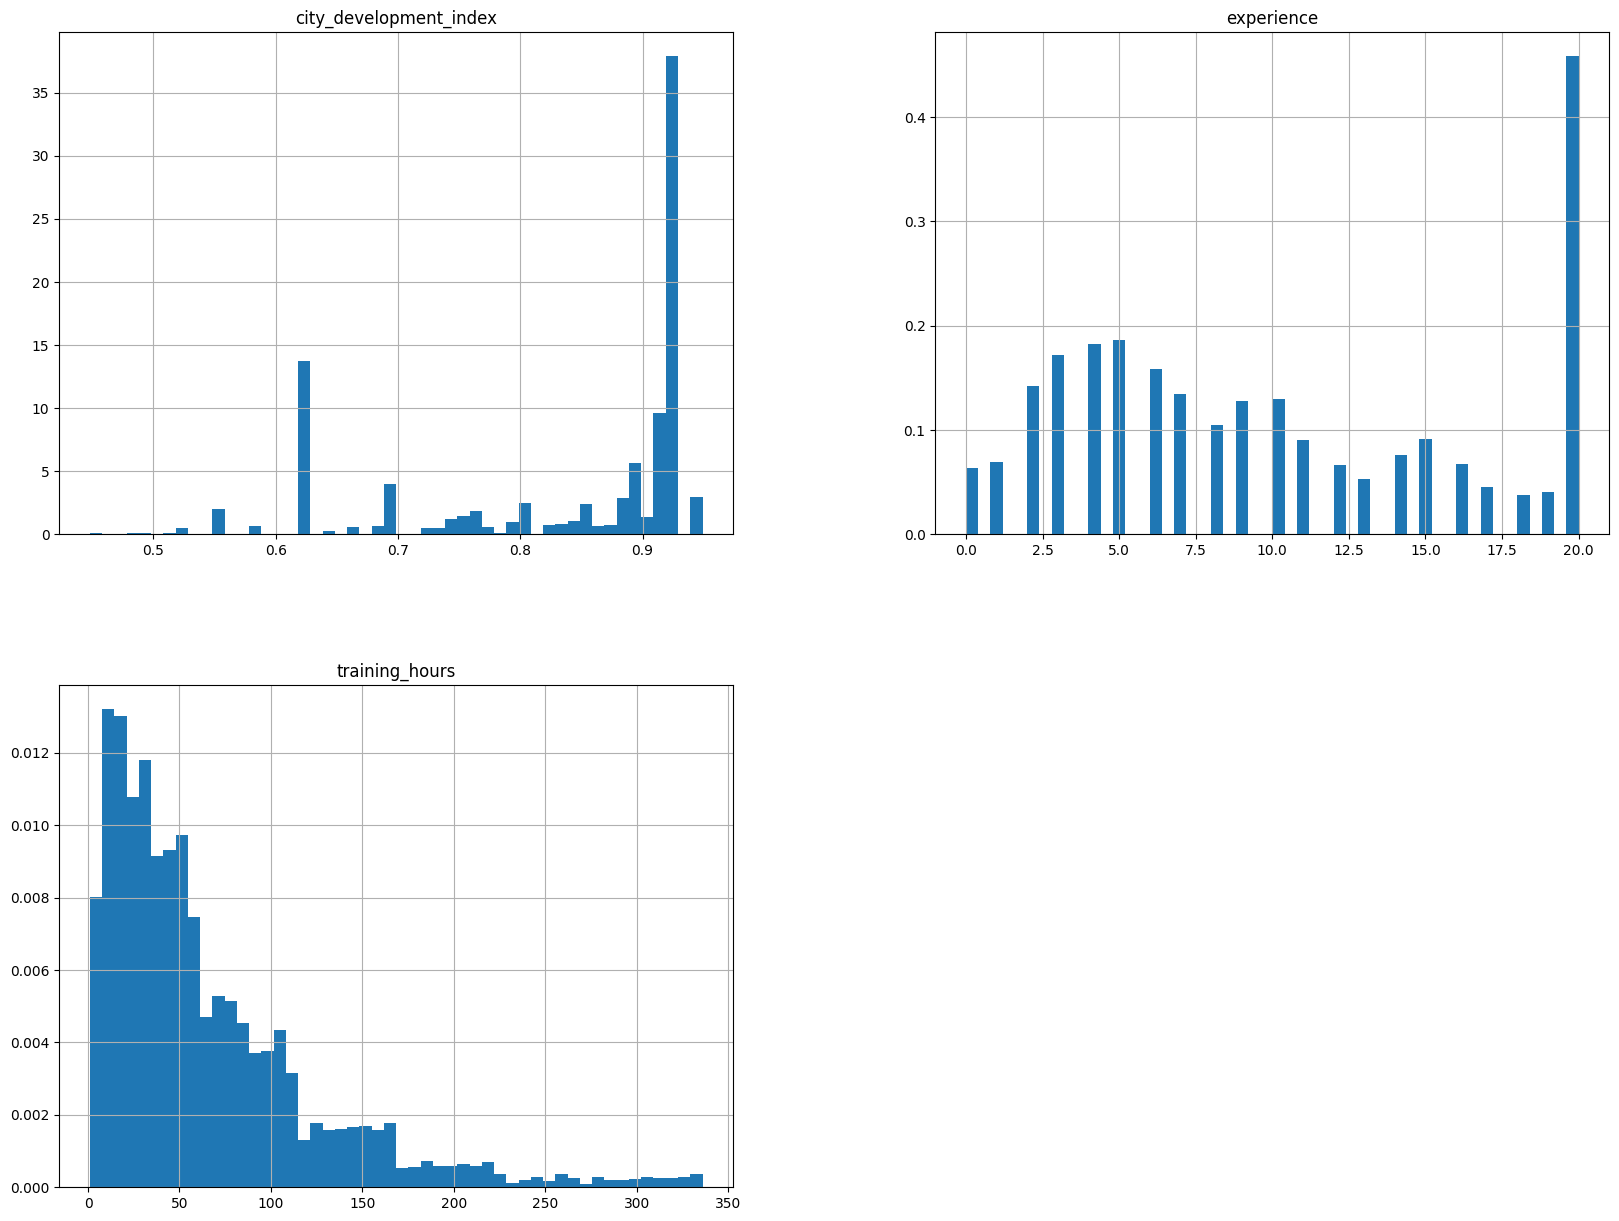

In [14]:
new_df.hist(bins=50, density=True, figsize=(20,15))
plt.show()

In [20]:
temp = pd.concat([
    # percentage of observations per category, orginal data
    df['enrolled_university'].value_counts() / len(df),
    # percentage of observation per. category , cca data
    new_df['enrolled_university'].value_counts() / len(new_df)
],
                 axis=1)

# add column names
temp.columns = ['orginal', 'cca']
temp

,orginal,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079
